In [1]:
import os
import warnings
os.environ["OMP_NUM_THREADS"] = "2"
warnings.filterwarnings("ignore")

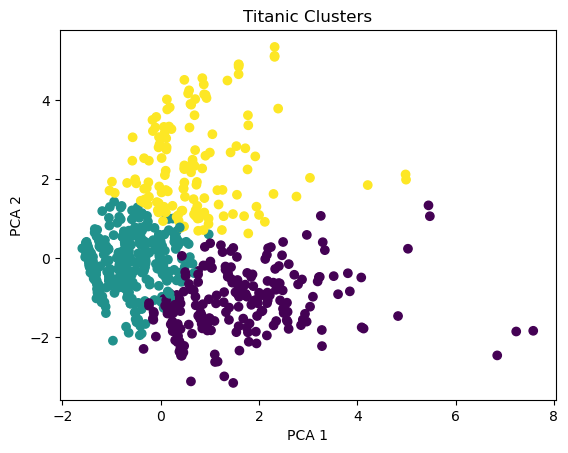

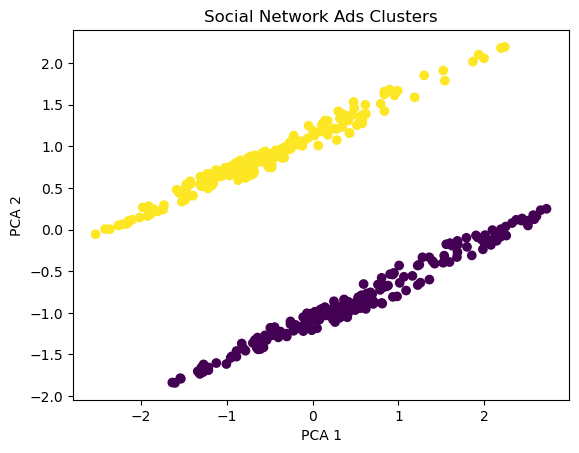

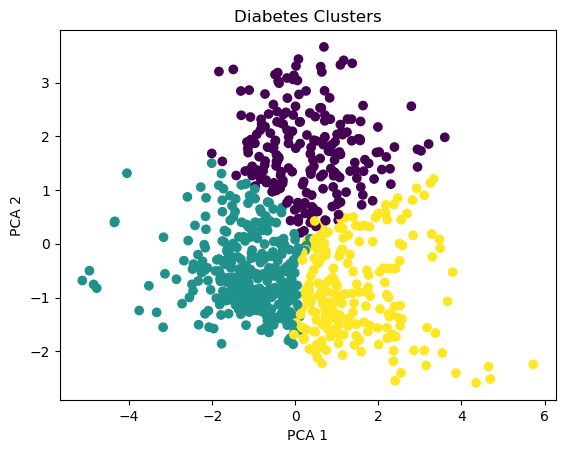

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def plot_clusters(X, labels, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.show()


df1 = pd.read_csv("titanic.csv")
df2 = pd.read_csv("Social_Network_Ads.csv")
df3 = pd.read_csv("diabetes_dataset.csv")


# TITANIC

df1 = df1.drop(["Name", "Ticket", "Cabin", "Survived"], axis=1)

df1["Age"] = df1["Age"].fillna(df1["Age"].mean())

df1["Embarked"] = df1["Embarked"].fillna(df1["Embarked"].mode()[0])

le = LabelEncoder()

df1["Sex"] = le.fit_transform(df1["Sex"])
df1["Embarked"] = le.fit_transform(df1["Embarked"])

X = df1.values

X = StandardScaler().fit_transform(X)

model = KMeans(n_clusters=3, random_state=42)

clusters = model.fit_predict(X)

plot_clusters(X, clusters, "Titanic Clusters")


# SOCIAL NETWORK ADS

df2 = df2.drop(["User ID", "Purchased"], axis=1)

df2["Gender"] = LabelEncoder().fit_transform(df2["Gender"])

X = df2.values

X = StandardScaler().fit_transform(X)

model = KMeans(n_clusters=2, random_state=42)

clusters = model.fit_predict(X)

plot_clusters(X, clusters, "Social Network Ads Clusters")


# DIABETES

X = df3.drop(["Outcome"], axis=1).values

X = StandardScaler().fit_transform(X)

model = KMeans(n_clusters=3, random_state=42)

clusters = model.fit_predict(X)

plot_clusters(X, clusters, "Diabetes Clusters")